<a href="https://colab.research.google.com/github/Razaurrahmanbennett/CSET_343/blob/main/LAB_2_e23cseu2442_razaur_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#RAZAUR RAHMAN
#E23CSEU2442

Cell 1 — Install libraries

In [1]:
!pip install -q seaborn pandas numpy scikit-learn matplotlib

Cell 2 — Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

print("Libraries imported successfully.")

Libraries imported successfully.


#1. Dataset Acquisition

The assignment asks for the Heart Failure Clinical Records Dataset.

Cell 3 — Download dataset

In [13]:
url = "https://raw.githubusercontent.com/hstrakna/Heart-Failure-Clinical-Records-Analysis/main/heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(url)

print("Dataset downloaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

Dataset downloaded successfully.
Dataset shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


#2. Load Dataset

The assignment requires reading the dataset as a Pandas DataFrame and displaying the first 5 rows.

Cell 4 — Display first 5 rows

In [14]:
print("First 5 rows of the dataset:")

display(df.head())

First 5 rows of the dataset:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


#3. Summarize Dataset

The assignment asks for:

Number of rows
Number of columns
Data types
Missing values
Cell 5 — Dataset summary

In [15]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
df.info()

Number of Rows: 299
Number of Columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Dataset Information:
<class 'pandas.core.f

Cell 6 — Missing-value summary

In [16]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

display(missing_summary)

,Missing Values,Missing Percentage
age,0,0.0
anaemia,0,0.0
creatinine_phosphokinase,0,0.0
diabetes,0,0.0
ejection_fraction,0,0.0
high_blood_pressure,0,0.0
platelets,0,0.0
serum_creatinine,0,0.0
serum_sodium,0,0.0
sex,0,0.0


#4. Visualize Missing Values

The assignment specifically asks for a heatmap using Seaborn.

Cell 7 — Missing-value heatmap

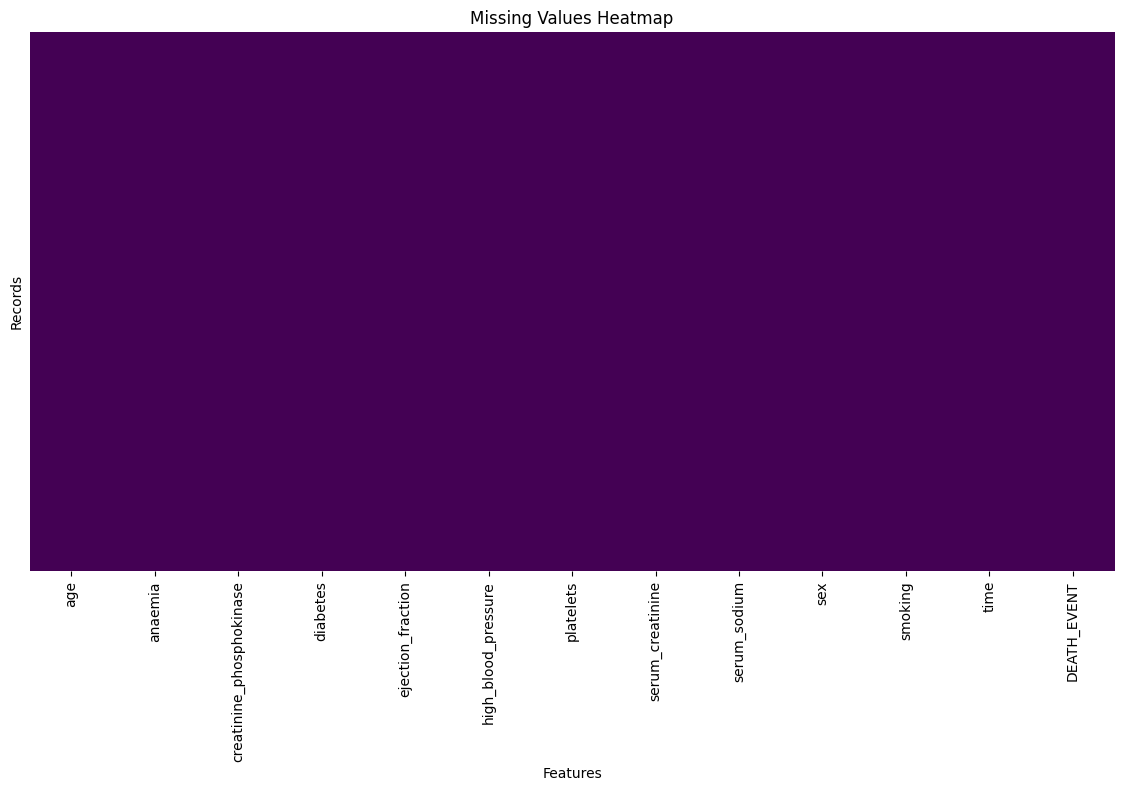

In [17]:
plt.figure(figsize=(14, 7))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Records")

plt.show()

#5. Plot Distributions

The assignment asks for histograms or boxplots of numerical features such as age and ejection_fraction.

Cell 8 — Histograms

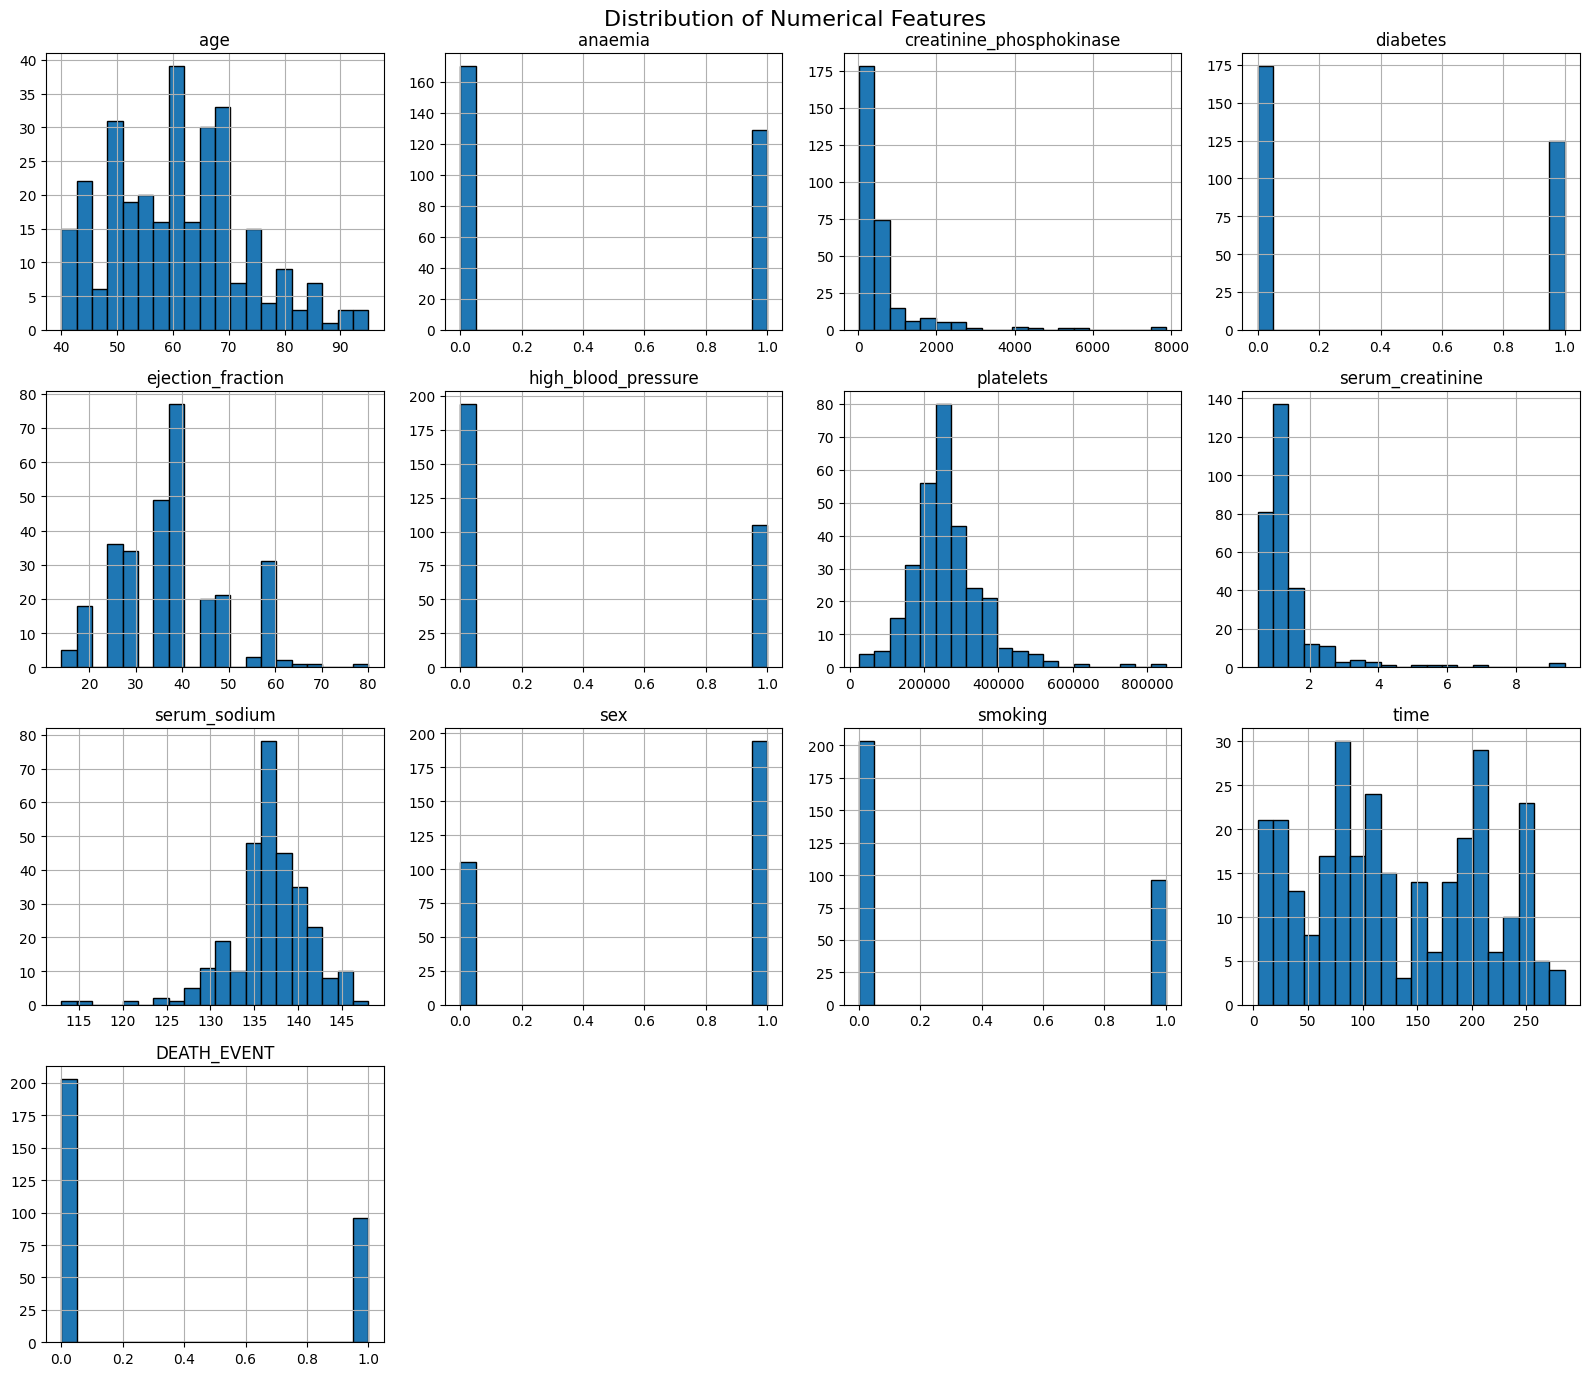

In [18]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

df[numerical_columns].hist(
    figsize=(16, 14),
    bins=20,
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

Cell 9 — Boxplots

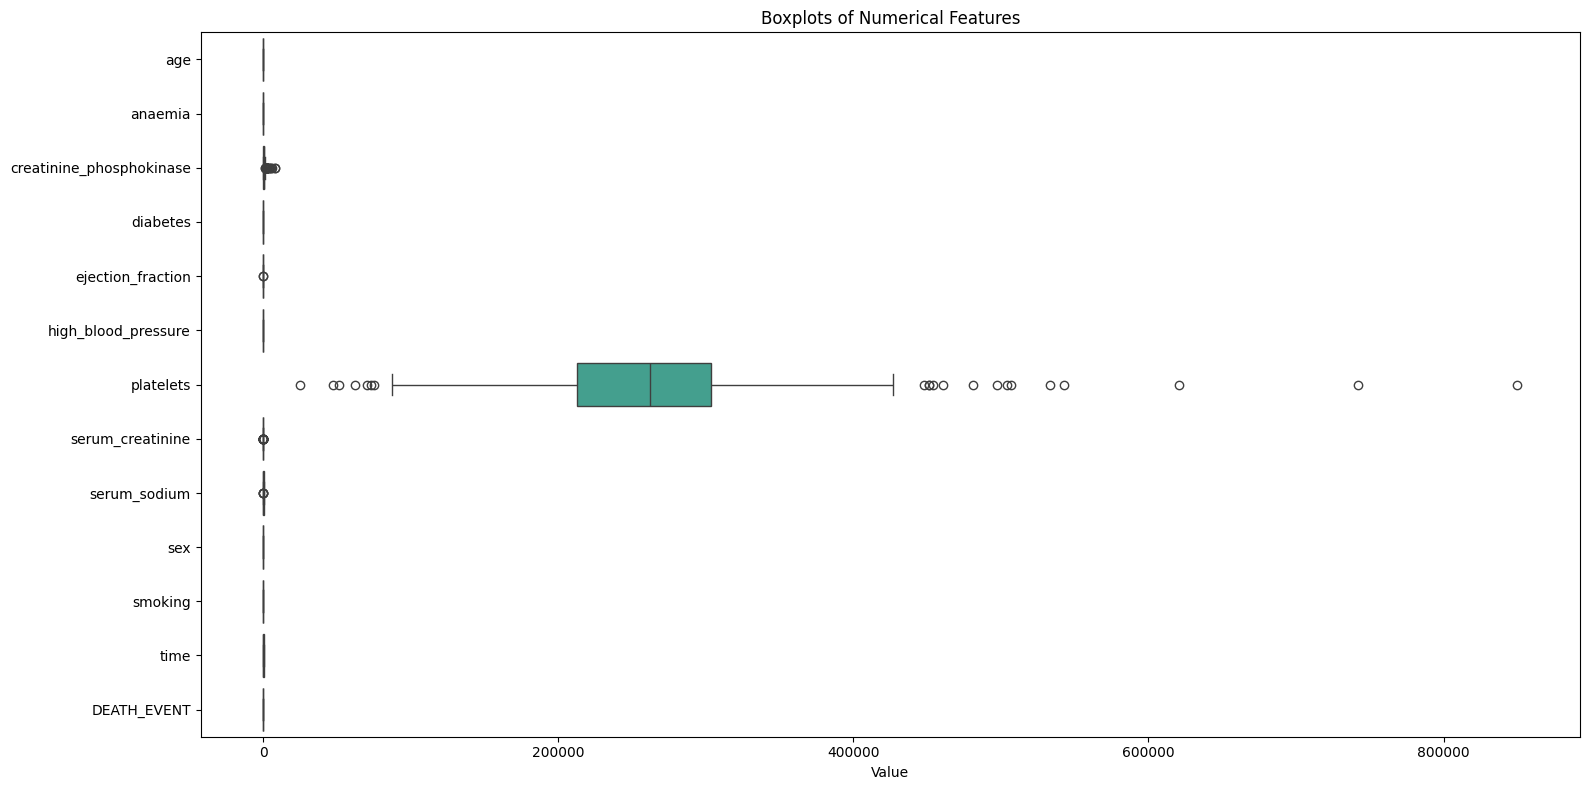

In [19]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=df[numerical_columns],
    orient="h"
)

plt.title("Boxplots of Numerical Features")
plt.xlabel("Value")

plt.tight_layout()
plt.show()

#6. Impute Missing Values

The assignment specifies:

Numerical features → mean or median
Categorical features → mode or "Unknown"
Cell 10 — Identify numerical and categorical columns

In [20]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Categorical Columns:
[]


Cell 11 — Impute missing values

In [21]:
# Create a copy before cleaning
cleaned_df = df.copy()

# Numerical columns:
# Use median because it is less affected by outliers
for column in numerical_columns:
    cleaned_df[column] = cleaned_df[column].fillna(
        cleaned_df[column].median()
    )

# Categorical columns:
# Use mode
for column in categorical_columns:
    if cleaned_df[column].isnull().any():
        cleaned_df[column] = cleaned_df[column].fillna(
            cleaned_df[column].mode()[0]
        )

print("Missing values after imputation:")
print(cleaned_df.isnull().sum())

Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


#7. Remove Outliers

The assignment explicitly requires removal of outliers.

We will use the IQR method.

Cell 12 — Detect and remove outliers

In [22]:
# Keep original number of rows
rows_before_outlier_removal = len(cleaned_df)

# Columns to check for outliers
outlier_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

# IQR method
for column in outlier_columns:

    Q1 = cleaned_df[column].quantile(0.25)
    Q3 = cleaned_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    cleaned_df = cleaned_df[
        (cleaned_df[column] >= lower_bound) &
        (cleaned_df[column] <= upper_bound)
    ]

rows_after_outlier_removal = len(cleaned_df)

print("Rows before outlier removal:",
      rows_before_outlier_removal)

print("Rows after outlier removal:",
      rows_after_outlier_removal)

print("Outliers removed:",
      rows_before_outlier_removal - rows_after_outlier_removal)

Rows before outlier removal: 299
Rows after outlier removal: 224
Outliers removed: 75


#8. Correct Inconsistencies

The assignment specifically gives examples such as negative age and asks to check/fix invalid entries.

Cell 13 — Check invalid values

In [23]:
print("Checking for invalid values...\n")

# Check negative age
print("Negative age values:")
print((cleaned_df["age"] < 0).sum())

# Check invalid ejection fraction
print("\nInvalid ejection fraction values:")
print(
    (
        (cleaned_df["ejection_fraction"] < 0) |
        (cleaned_df["ejection_fraction"] > 100)
    ).sum()
)

# Check invalid serum sodium
print("\nInvalid serum sodium values:")
print((cleaned_df["serum_sodium"] <= 0).sum())

# Check invalid serum creatinine
print("\nInvalid serum creatinine values:")
print((cleaned_df["serum_creatinine"] <= 0).sum())

Checking for invalid values...

Negative age values:
0

Invalid ejection fraction values:
0

Invalid serum sodium values:
0

Invalid serum creatinine values:
0


Cell 14 — Correct invalid entries

In [24]:
# Replace invalid values with NaN

cleaned_df.loc[
    cleaned_df["age"] < 0,
    "age"
] = np.nan

cleaned_df.loc[
    (cleaned_df["ejection_fraction"] < 0) |
    (cleaned_df["ejection_fraction"] > 100),
    "ejection_fraction"
] = np.nan

cleaned_df.loc[
    cleaned_df["serum_sodium"] <= 0,
    "serum_sodium"
] = np.nan

cleaned_df.loc[
    cleaned_df["serum_creatinine"] <= 0,
    "serum_creatinine"
] = np.nan


# Impute newly corrected missing numerical values
for column in numerical_columns:
    if column in cleaned_df.columns:
        cleaned_df[column] = cleaned_df[column].fillna(
            cleaned_df[column].median()
        )

print("Invalid entries corrected successfully.")

Invalid entries corrected successfully.


#9. Feature Engineering

The assignment specifically requires:

age_group
<40
40–60
>60
risk_score
based on normalized product of ejection_fraction and serum_creatinine
Cell 15 — Create age_group

In [25]:
def create_age_group(age):

    if age < 40:
        return "<40"

    elif age <= 60:
        return "40-60"

    else:
        return ">60"


cleaned_df["age_group"] = cleaned_df["age"].apply(
    create_age_group
)

print("Age groups created:")
print(cleaned_df["age_group"].value_counts())

Age groups created:
age_group
40-60    115
>60      109
Name: count, dtype: int64


Cell 16 — Create normalized risk score

In [26]:
# Normalize ejection_fraction
ef_min = cleaned_df["ejection_fraction"].min()
ef_max = cleaned_df["ejection_fraction"].max()

cleaned_df["ejection_fraction_norm"] = (
    (cleaned_df["ejection_fraction"] - ef_min) /
    (ef_max - ef_min)
)

# Normalize serum_creatinine
cr_min = cleaned_df["serum_creatinine"].min()
cr_max = cleaned_df["serum_creatinine"].max()

cleaned_df["serum_creatinine_norm"] = (
    (cleaned_df["serum_creatinine"] - cr_min) /
    (cr_max - cr_min)
)

# Normalized product
cleaned_df["risk_score"] = (
    cleaned_df["ejection_fraction_norm"] *
    cleaned_df["serum_creatinine_norm"]
)

print("Risk score created successfully.")

display(
    cleaned_df[
        [
            "ejection_fraction",
            "serum_creatinine",
            "risk_score"
        ]
    ].head()
)

Risk score created successfully.


,ejection_fraction,serum_creatinine,risk_score
0,20.0,1.9,0.101961
2,20.0,1.3,0.054902
3,20.0,1.9,0.101961
5,40.0,2.1,0.509804
6,15.0,1.2,0.007843


#10. Encode Categorical Variables

The assignment asks for one-hot or label encoding of categorical variables such as sex and smoking.

In this dataset, sex and smoking are stored as binary numeric variables, while our engineered age_group is categorical.

Cell 17 — One-hot encode age_group

In [27]:
encoded_df = pd.get_dummies(
    cleaned_df,
    columns=["age_group"],
    prefix="age_group",
    dtype=int
)

print("Categorical variable encoded successfully.")

display(encoded_df.head())

Categorical variable encoded successfully.


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,ejection_fraction_norm,serum_creatinine_norm,risk_score,age_group_40-60,age_group_>60
0,75.0,0,582,0,20.0,1,265000.0,1.9,130.0,1,0,4,1,0.117647,0.866667,0.101961,0,1
2,65.0,0,146,0,20.0,0,162000.0,1.3,129.0,1,1,7,1,0.117647,0.466667,0.054902,0,1
3,50.0,1,111,0,20.0,0,210000.0,1.9,137.0,1,0,7,1,0.117647,0.866667,0.101961,1,0
5,90.0,1,47,0,40.0,1,204000.0,2.1,132.0,1,1,8,1,0.509804,1.000000,0.509804,0,1
6,75.0,1,246,0,15.0,0,127000.0,1.2,137.0,1,0,10,1,0.019608,0.400000,0.007843,0,1


#11. Normalize Features

The assignment requires scaling numerical features such as age and platelets to 0–1 using MinMaxScaler.

Cell 18 — MinMaxScaler

In [28]:
# Numerical columns for normalization

scale_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

scaler = MinMaxScaler()

encoded_df[scale_columns] = scaler.fit_transform(
    encoded_df[scale_columns]
)

print("Numerical features normalized to 0-1.")

display(
    encoded_df[scale_columns].head()
)

Numerical features normalized to 0-1.


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
0,0.636364,0.470990,0.117647,0.468852,0.866667,0.217391
2,0.454545,0.098976,0.117647,0.131148,0.466667,0.173913
3,0.181818,0.069113,0.117647,0.288525,0.866667,0.521739
5,0.909091,0.014505,0.509804,0.268852,1.000000,0.304348
6,0.636364,0.184300,0.019608,0.016393,0.400000,0.521739


Cell 19 — Verify normalization

In [29]:
normalization_check = encoded_df[
    scale_columns
].agg(["min", "max"])

display(normalization_check)

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
min,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0


#12. Compute Summary Statistics

The assignment requires calculating mean, median and standard deviation before and after cleaning.

Cell 20 — Before cleaning statistics

In [30]:
statistics_before = df[
    numerical_columns
].agg(
    ["mean", "median", "std"]
).T

statistics_before.columns = [
    "Mean_Before",
    "Median_Before",
    "Std_Before"
]

print("Statistics Before Cleaning:")
display(statistics_before)

Statistics Before Cleaning:


,Mean_Before,Median_Before,Std_Before
age,60.833893,60.0,11.894809
anaemia,0.431438,0.0,0.496107
creatinine_phosphokinase,581.839465,250.0,970.287881
diabetes,0.418060,0.0,0.494067
ejection_fraction,38.083612,38.0,11.834841
high_blood_pressure,0.351171,0.0,0.478136
platelets,263358.029264,262000.0,97804.236869
serum_creatinine,1.393880,1.1,1.034510
serum_sodium,136.625418,137.0,4.412477
sex,0.648829,1.0,0.478136


Cell 21 — After cleaning statistics

In [31]:
statistics_after = cleaned_df[
    numerical_columns
].agg(
    ["mean", "median", "std"]
).T

statistics_after.columns = [
    "Mean_After",
    "Median_After",
    "Std_After"
]

print("Statistics After Cleaning:")
display(statistics_after)

Statistics After Cleaning:


,Mean_After,Median_After,Std_After
age,60.809527,60.0,11.946085
anaemia,0.468750,0.0,0.500140
creatinine_phosphokinase,336.941964,212.0,279.521085
diabetes,0.419643,0.0,0.494606
ejection_fraction,38.178571,38.0,11.710801
high_blood_pressure,0.379464,0.0,0.486340
platelets,255865.190045,262500.0,67153.749051
serum_creatinine,1.128571,1.1,0.327794
serum_sodium,137.044643,137.0,3.806740
sex,0.642857,1.0,0.480231


Cell 22 — Compare before and after

In [32]:
statistics_comparison = pd.concat(
    [
        statistics_before,
        statistics_after
    ],
    axis=1
)

print("Comparison of Statistics:")
display(statistics_comparison)

Comparison of Statistics:


,Mean_Before,Median_Before,Std_Before,Mean_After,Median_After,Std_After
age,60.833893,60.0,11.894809,60.809527,60.0,11.946085
anaemia,0.431438,0.0,0.496107,0.468750,0.0,0.500140
creatinine_phosphokinase,581.839465,250.0,970.287881,336.941964,212.0,279.521085
diabetes,0.418060,0.0,0.494067,0.419643,0.0,0.494606
ejection_fraction,38.083612,38.0,11.834841,38.178571,38.0,11.710801
high_blood_pressure,0.351171,0.0,0.478136,0.379464,0.0,0.486340
platelets,263358.029264,262000.0,97804.236869,255865.190045,262500.0,67153.749051
serum_creatinine,1.393880,1.1,1.034510,1.128571,1.1,0.327794
serum_sodium,136.625418,137.0,4.412477,137.044643,137.0,3.806740
sex,0.648829,1.0,0.478136,0.642857,1.0,0.480231


#13. Validate Cleaning

The assignment requires plotting histograms or boxplots of the cleaned numerical features.

Cell 23 — Cleaned histograms

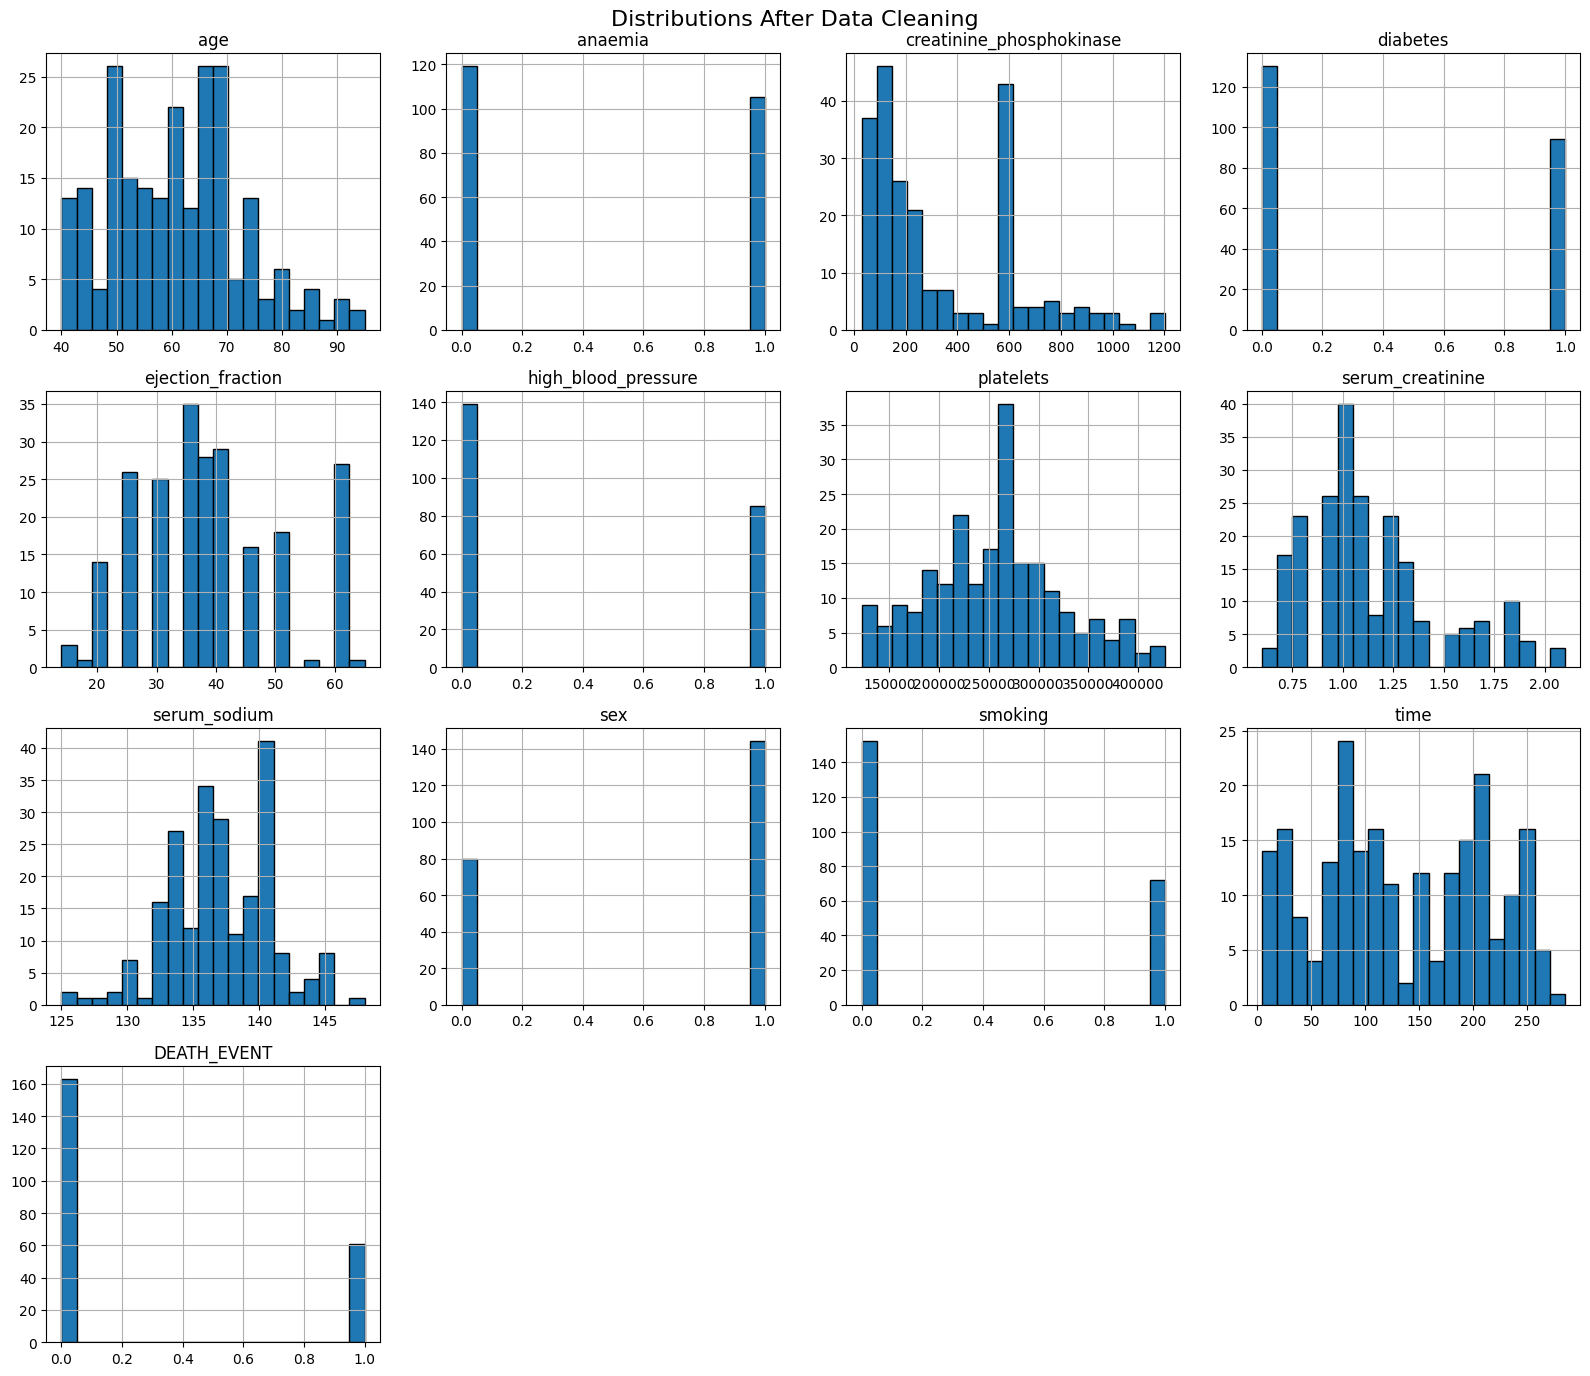

In [33]:
cleaned_df[numerical_columns].hist(
    figsize=(16, 14),
    bins=20,
    edgecolor="black"
)

plt.suptitle(
    "Distributions After Data Cleaning",
    fontsize=16
)

plt.tight_layout()
plt.show()

Cell 24 — Cleaned boxplots

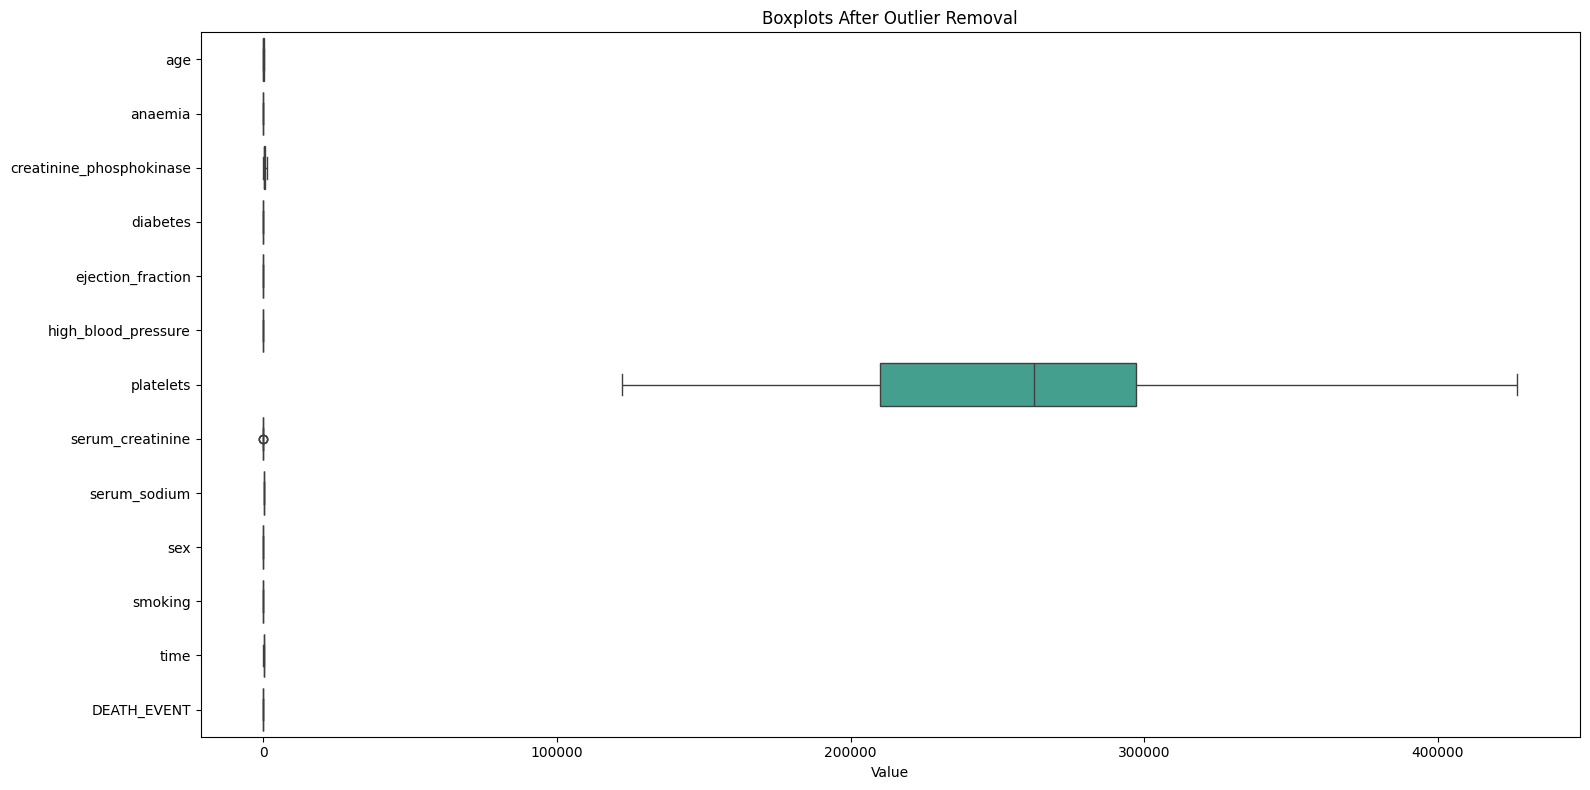

In [34]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=cleaned_df[numerical_columns],
    orient="h"
)

plt.title("Boxplots After Outlier Removal")
plt.xlabel("Value")

plt.tight_layout()
plt.show()

#14. Check Missing Values

The final requirement is to confirm that no missing values remain or justify any remaining values.

Cell 25 — Final missing-value check

In [35]:
final_missing = cleaned_df.isnull().sum()

print("Final Missing Value Check:")
print(final_missing)

print("\nTotal missing values:",
      final_missing.sum())

if final_missing.sum() == 0:
    print("\n✓ No missing values remain.")
else:
    print("\n⚠ Missing values still remain.")

Final Missing Value Check:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
age_group                   0
ejection_fraction_norm      0
serum_creatinine_norm       0
risk_score                  0
dtype: int64

Total missing values: 0

✓ No missing values remain.


Final Dataset
Cell 26 — Display final cleaned dataset

In [36]:
print("Original Dataset Shape:")
print(df.shape)

print("\nCleaned Dataset Shape:")
print(cleaned_df.shape)

print("\nEncoded Dataset Shape:")
print(encoded_df.shape)

print("\nFinal Cleaned Dataset:")
display(cleaned_df.head())

Original Dataset Shape:
(299, 13)

Cleaned Dataset Shape:
(224, 17)

Encoded Dataset Shape:
(224, 18)

Final Cleaned Dataset:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,age_group,ejection_fraction_norm,serum_creatinine_norm,risk_score
0,75.0,0,582,0,20.0,1,265000.0,1.9,130.0,1,0,4,1,>60,0.117647,0.866667,0.101961
2,65.0,0,146,0,20.0,0,162000.0,1.3,129.0,1,1,7,1,>60,0.117647,0.466667,0.054902
3,50.0,1,111,0,20.0,0,210000.0,1.9,137.0,1,0,7,1,40-60,0.117647,0.866667,0.101961
5,90.0,1,47,0,40.0,1,204000.0,2.1,132.0,1,1,8,1,>60,0.509804,1.000000,0.509804
6,75.0,1,246,0,15.0,0,127000.0,1.2,137.0,1,0,10,1,>60,0.019608,0.400000,0.007843


Cell 27 — Complete final summary

In [37]:
print("=" * 70)
print("LAB ASSIGNMENT - 2 : FINAL SUMMARY")
print("=" * 70)

print("\n1. Dataset Acquisition       : Completed")
print("2. Dataset Loading           : Completed")
print("3. Dataset Summary           : Completed")
print("4. Missing Value Heatmap     : Completed")
print("5. Feature Distributions     : Completed")
print("6. Missing Value Imputation  : Completed")
print("7. Outlier Removal           : Completed")
print("8. Inconsistency Correction  : Completed")
print("9. Feature Engineering       : Completed")
print("10. Categorical Encoding     : Completed")
print("11. Feature Normalization    : Completed")
print("12. Summary Statistics       : Completed")
print("13. Cleaning Validation      : Completed")
print("14. Final Missing Check      : Completed")

print("\nOriginal Rows:", len(df))
print("Cleaned Rows:", len(cleaned_df))
print("Rows Removed:", len(df) - len(cleaned_df))

print("Final Missing Values:",
      cleaned_df.isnull().sum().sum())

print("\n" + "=" * 70)
print("DATA CLEANING AND ENRICHMENT COMPLETED")
print("=" * 70)

LAB ASSIGNMENT - 2 : FINAL SUMMARY

1. Dataset Acquisition       : Completed
2. Dataset Loading           : Completed
3. Dataset Summary           : Completed
4. Missing Value Heatmap     : Completed
5. Feature Distributions     : Completed
6. Missing Value Imputation  : Completed
7. Outlier Removal           : Completed
8. Inconsistency Correction  : Completed
9. Feature Engineering       : Completed
10. Categorical Encoding     : Completed
11. Feature Normalization    : Completed
12. Summary Statistics       : Completed
13. Cleaning Validation      : Completed
14. Final Missing Check      : Completed

Original Rows: 299
Cleaned Rows: 224
Rows Removed: 75
Final Missing Values: 0

DATA CLEANING AND ENRICHMENT COMPLETED
